In this notebook we analyze a dataset detailing the share of the world population with 
at least basic education.
the dataset includes key columns such as the country/entity, year of record, and 
percentages related to educational attainment.
A curiosity here is how historical trends in educational can help inform future projections,
which we aim to explore further in prediction section.

In [1]:
# Importing all necessary libraries.
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg') # Ensure matplotlib uses a non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg') # Use the Agg backend if only plt is imported

get_ipython().run_line_magic('matplotlib','inline')

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For prediction
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Set styles for plots
sns.set(style='whitegrid')

In [3]:
df = pd.read_csv('Downloads/share-of-the-world-population-with-at-least-basic-education.csv')
df.head()

,Entity,Code,Year,Share of population with no education,Share of population with at least some basic education
0,Argentina,ARG,1950,14.211617,85.788380
1,Argentina,ARG,1955,12.431603,87.568400
2,Argentina,ARG,1960,10.859231,89.140770
3,Argentina,ARG,1965,9.377147,90.622856
4,Argentina,ARG,1970,8.031716,91.968285


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 5 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Entity                                                  815 non-null    object 
 1   Code                                                    815 non-null    object 
 2   Year                                                    815 non-null    int64  
 3   Share of population with no education                   815 non-null    float64
 4   Share of population with at least some basic education  815 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 32.0+ KB


In [7]:
 df.shape

(815, 5)

# Data Cleaning and Preprocessing


In [10]:
# Checking of missing values.
print('Missing Values in each column: ')
print(df.isnull().sum())

Missing Values in each column: 
Entity                                                    0
Code                                                      0
Year                                                      0
Share of population with no education                     0
Share of population with at least some basic education    0
dtype: int64


In [12]:
# Type  conversion for Year column: converting year to datetime using the year only format.
df['Year_dt'] = pd.to_datetime(df['Year'], format='%Y')
# Display info about the dateframe
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 6 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Entity                                                  815 non-null    object        
 1   Code                                                    815 non-null    object        
 2   Year                                                    815 non-null    int64         
 3   Share of population with no education                   815 non-null    float64       
 4   Share of population with at least some basic education  815 non-null    float64       
 5   Year_dt                                                 815 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 38.3+ KB


,Entity,Code,Year,Share of population with no education,Share of population with at least some basic education,Year_dt
0,Argentina,ARG,1950,14.211617,85.788380,1950-01-01
1,Argentina,ARG,1955,12.431603,87.568400,1955-01-01
2,Argentina,ARG,1960,10.859231,89.140770,1960-01-01
3,Argentina,ARG,1965,9.377147,90.622856,1965-01-01
4,Argentina,ARG,1970,8.031716,91.968285,1970-01-01


# Exploratory Data Analysis

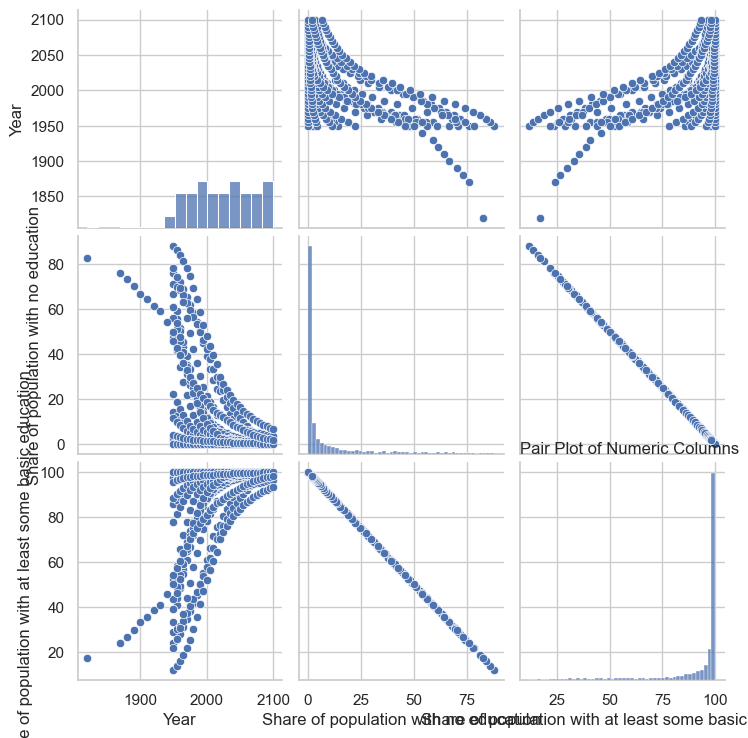

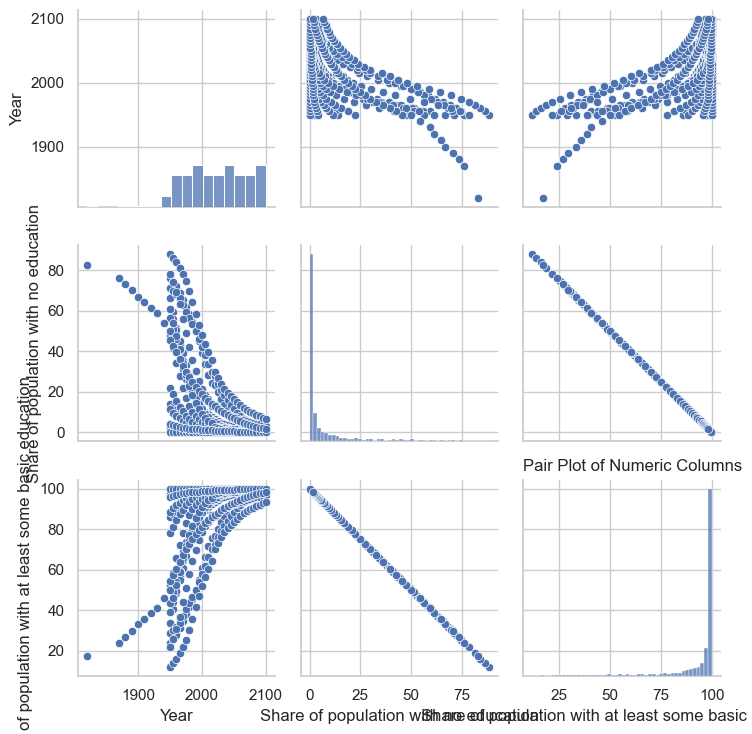

In [19]:
# Visualizing distribution of numeric columns.
numeric_df = df.select_dtypes(include=[np.number])

# Pair Plot to observe relationships
sns.pairplot(numeric_df.dropna())
plt.title('Pair Plot of Numeric Columns', loc='left')
plt.tight_layout()
plt.show()

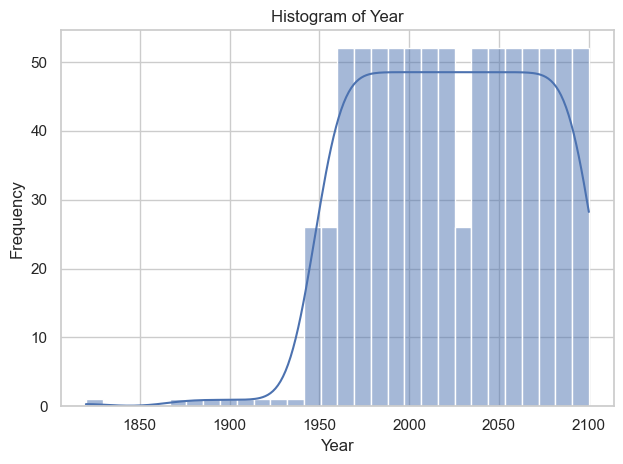

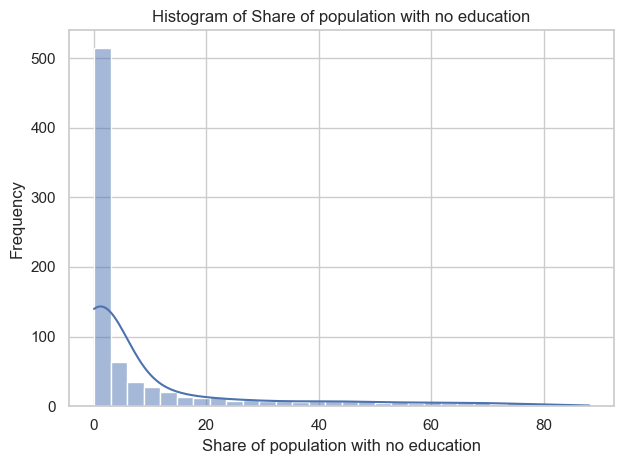

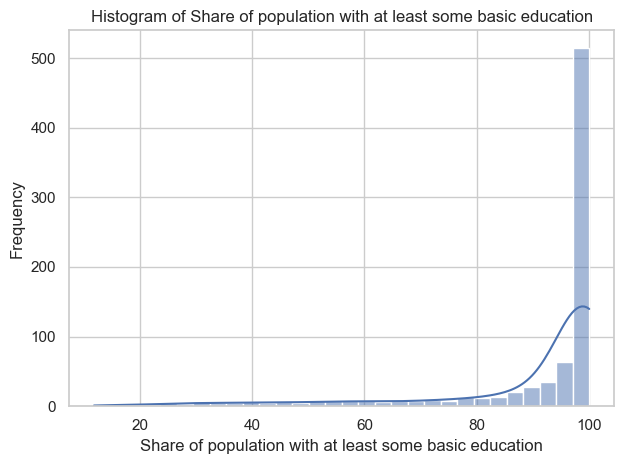

In [21]:
# Histograms for each numeric column
numeric_columns = numeric_df.columns
for col in numeric_columns:
    plt.figure()
    sns.histplot(numeric_df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

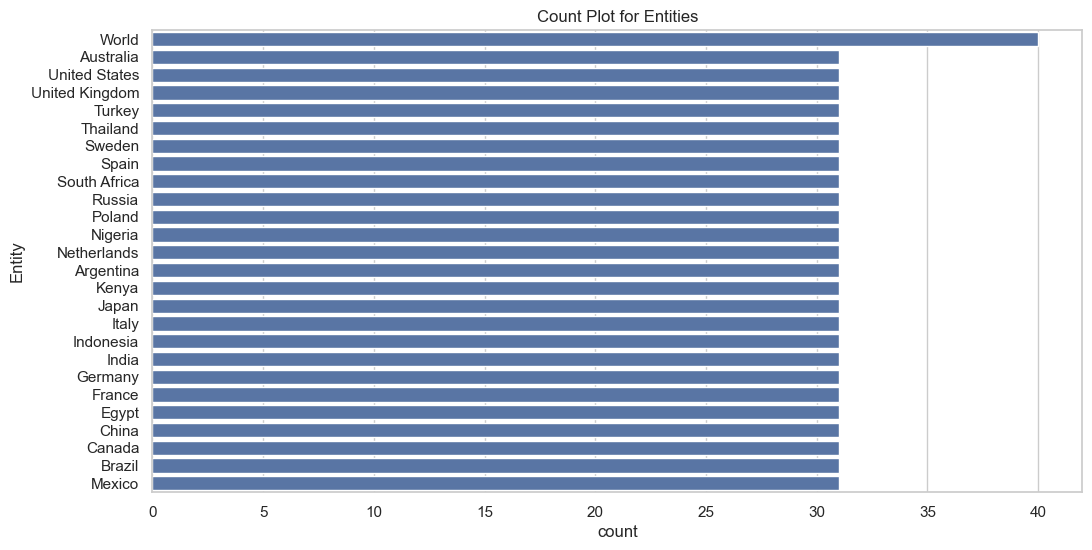

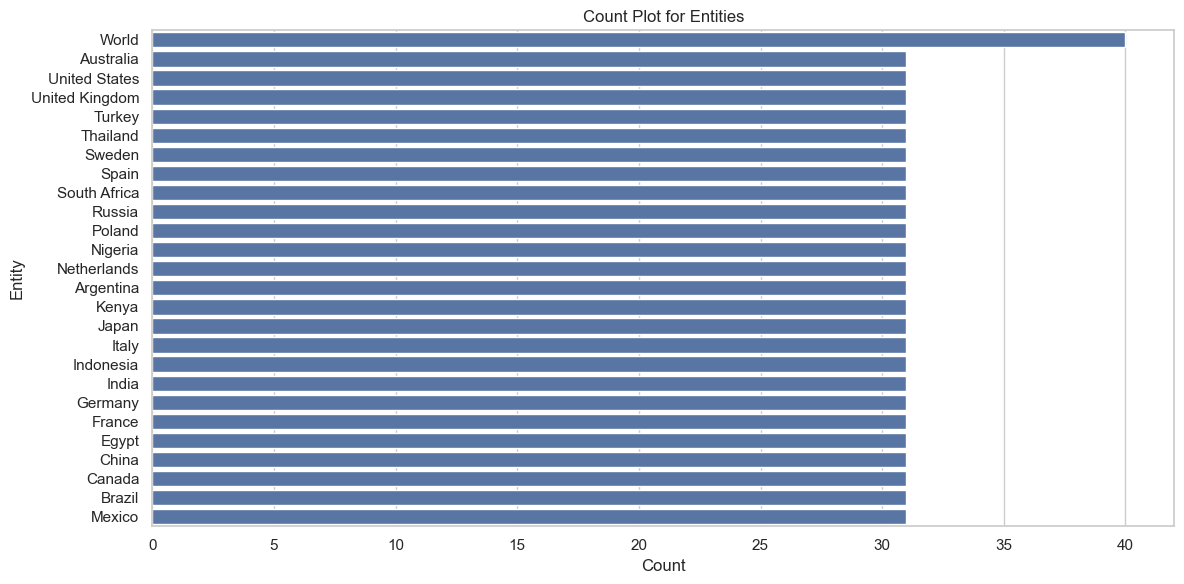

In [25]:
# count plot for the 'Entity' column to understand categorical_distribution.
plt.figure(figsize=(12, 6))
sns.countplot(y='Entity', data=df, order = df['Entity'].value_counts().index)
plt.title('Count Plot for Entities')
plt.xlabel('Count')
plt.ylabel('Entity')
plt.tight_layout()
plt.show()

# Model Prediction.
In this section, we attempt to build a simple prediction model. The task is to predict  the
share of the population with at least some basic education based on the year.

In [28]:
# .dropna() removes rows where any of these two columns has missing (NaN) values
model_df = df[['Year', 'Share of population with at least some basic education']].dropna()

# Define feature and target.
X = model_df[['Year']]
y = model_df['Share of population with at least some basic education']

# Spliting data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state =42)

#Building the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
# Make predicitons
y_pred = model.predict(X_test)

In [32]:
# Evaluate the model using R^2 score
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score of the prediction model: {r2:.3f}')

R^2 Score of the prediction model: 0.269


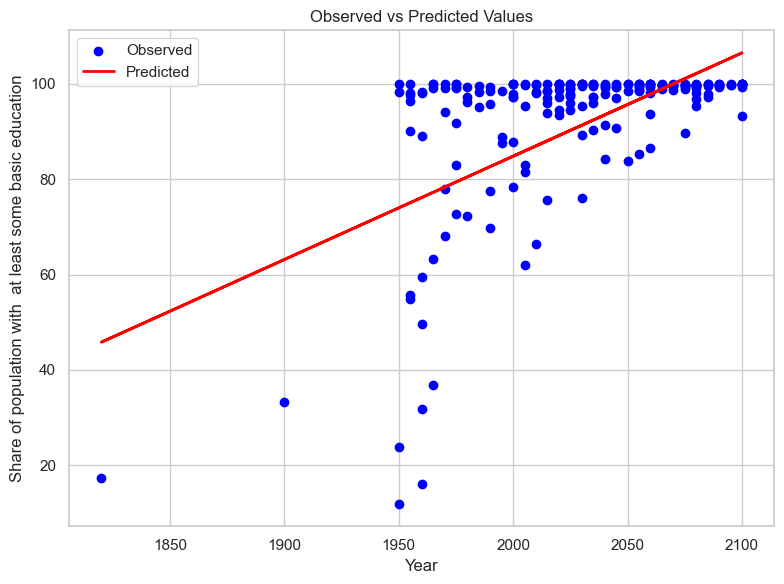

In [34]:
# Plotting observed vs prediction values.
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label = 'Observed')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Year')
plt.ylabel('Share of population with  at least some basic education')
plt.title('Observed vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion
Our exploration of the dataset has provided interesting insights into global education trends over time. We observed the distribution of educational attainment and built a simple linear regression model to predict the share of the population with at least some basic education based on the year. Although the predictor provides a baseline measure of the trend, there are many avenues for further investigation. Future analysis might include:

Incorporating additional features such as regional or economic indicators
Utilizing time series forecasting methods to capture non-linear trends
Performing clustering analysis on entities to discern common patterns in education trends
We hope that this notebook serves as a useful starting point for your analysis. If you found this exploration helpful, please consider an upvote.

Happy analyzing.